# Enterprise Retrieval-Augmented Generation (RAG) System
### End-to-End High-Performance RAG Chatbot for Large PDF Corpora (≥10 PDFs, ≥200 Pages each)

**Architecture Features & Specifications:**
- **Phase 1: Ingestion & Document Digitization Pipeline**: PyMuPDF native page extraction + RapidOCR ONNX Runtime fallback engine for scanned graphics/pages.
- **Phase 2: Page-Locked Chunking & Mapping**: Word-boundary sliding window chunker (350 words, 75 overlap) for tight semantic passages.
- **Phase 3: Vector Encoding & Space Indexing**: `BAAI/bge-small-en-v1.5` dense embedding + Persistent ChromaDB with HNSW spatial graph index (`hnsw:space`: `cosine`).
- **Phase 4: Runtime Query Execution & Cross-Encoder Reranking**: Spatial query vector encoding, top-20 ANN candidate lookup, `cross-encoder/ms-marco-MiniLM-L-6-v2` reranking, and Ollama `qwen2.5:1.5b` LLM answer synthesis with exact source citations.
- **2–5 Second SLA Target**: Sub-2s response latency with high retrieval and factual extraction accuracy.

---

In [21]:
!apt-get update && apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!pip install -q PyMuPDF rapidocr_onnxruntime sentence-transformers chromadb transformers torch pillow matplotlib pandas tqdm ipywidgets requests

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Fetched 384 kB in 2s (245 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem 

In [22]:
# Step 0: Dependency Imports & Ollama Server Startup
import os
import re
import io
import json
import time
import glob
import shutil
import subprocess
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import fitz  # PyMuPDF
from rapidocr_onnxruntime import RapidOCR
from sentence_transformers import SentenceTransformer, CrossEncoder
import chromadb

# Start Ollama server process in background
print("Starting Ollama server in background...")
subprocess.Popen(["ollama", "serve"])
time.sleep(3)

# Pull high-precision model (qwen2.5:1.5b) for QA extraction
print("Pulling qwen2.5:1.5b model...")
subprocess.run(["ollama", "pull", "qwen2.5:1.5b"], check=True)

print("Ollama and Python dependencies successfully initialized.")

Starting Ollama server in background...
Pulling qwen2.5:1.5b model...
Ollama and Python dependencies successfully initialized.


## Phase 1: Ingestion & Document Digitization Pipeline
1. **Scan Discovery**: Locate all `.pdf` documents in Colab storage (`data/` or uploaded Google Drive folder).
2. **Sequential Page Processing**: Attempt native layout text extraction per page using PyMuPDF (`fitz`).
3. **RapidOCR Fallback Trigger**: If native text string length < 20 characters, mark as scanned page, render at 200 DPI into an in-memory byte stream, and execute RapidOCR ONNX Runtime engine.
4. **Text Normalization**: Apply regular expressions to condense whitespaces and strip running page numbers, headers, and footers.
5. **Structured Buffer Assembly**: Package cleaned page strings into flat array: `{"filename": str, "page_number": int, "text": str}`.

In [23]:
class DocumentDigitizer:
    """Handles native PDF parsing, RapidOCR fallback, and layout text normalization."""
    def __init__(self, min_text_len=20, dpi=200):
        self.min_text_len = min_text_len
        self.dpi = dpi
        print("Initializing RapidOCR ONNX Runtime execution engine...")
        self.ocr_engine = RapidOCR()

    def clean_text(self, text: str) -> str:
        """Normalize whitespaces and remove header/footer noise."""
        text = re.sub(r"\s+", " ", text)
        text = re.sub(r"Page \d+ of \d+", "", text, flags=re.IGNORECASE)
        text = re.sub(r"^\s*\d+\s*$", "", text, flags=re.MULTILINE)
        return text.strip()

    def ocr_page(self, page: fitz.Page) -> str:
        """Render page bitmap to in-memory byte stream and process with RapidOCR."""
        pix = page.get_pixmap(dpi=self.dpi)
        img_bytes = pix.tobytes("png")
        result, _ = self.ocr_engine(img_bytes)
        if result:
            ocr_text = " ".join([line[1] for line in result])
            return ocr_text
        return ""

    def extract_pdf_pages(self, pdf_path: str) -> list:
        """Process a PDF page by page with native text check + RapidOCR fallback."""
        filename = os.path.basename(pdf_path)
        doc = fitz.open(pdf_path)
        page_buffers = []

        for page_idx, page in enumerate(doc, start=1):
            native_text = page.get_text()

            # RapidOCR Fallback Trigger
            if len(native_text.strip()) < self.min_text_len:
                try:
                    extracted_text = self.ocr_page(page)
                except Exception as e:
                    extracted_text = native_text
            else:
                extracted_text = native_text

            cleaned = self.clean_text(extracted_text)
            if cleaned:
                page_buffers.append({
                    "filename": filename,
                    "page_number": page_idx,
                    "text": cleaned
                })
        doc.close()
        return page_buffers

    def process_folder(self, pdf_folder: str) -> list:
        """Scan directory and aggregate structured page buffers."""
        pdf_files = sorted(glob.glob(os.path.join(pdf_folder, "*.pdf")))
        print(f"Found {len(pdf_files)} PDF document(s) in '{pdf_folder}'.")
        all_page_buffers = []

        for pdf_path in tqdm(pdf_files, desc="Digitizing PDFs"):
            pages = self.extract_pdf_pages(pdf_path)
            all_page_buffers.extend(pages)

        print(f"Phase 1 Complete: Digitized {len(all_page_buffers)} total pages.")
        return all_page_buffers

## Phase 2: Page-Locked Chunking & Mapping
1. **Chunk Generation**: Sliding word window over text with 350 word boundary limit and 75 word overlap for tight semantic passages.
2. **Metadata Binding**: Explicitly clone and bind parent `filename` and `page_number` to each chunk.
3. **Persistence Export**: Export structured chunk list directly onto disk as `chunks.json`.

In [24]:
class PageLockedChunker:
    """Splits digitized page buffers into overlapping word passages with page-locked metadata."""
    def __init__(self, chunk_size=350, chunk_overlap=75):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap

    def chunk_page_text(self, text: str) -> list:
        """Sliding window text chunker."""
        words = text.split()
        if not words:
            return []

        chunks = []
        start = 0
        step = self.chunk_size - self.chunk_overlap
        if step <= 0:
            step = max(1, self.chunk_size // 2)

        while start < len(words):
            end = min(start + self.chunk_size, len(words))
            passage = " ".join(words[start:end])
            chunks.append(passage)
            if end == len(words):
                break
            start += step
        return chunks

    def process_and_save(self, page_buffers: list, output_file: str = "chunks.json") -> list:
        """Process structured page buffer list and export to JSON file."""
        all_chunks = []
        for entry in tqdm(page_buffers, desc="Chunking Pages (350 words)"):
            filename = entry["filename"]
            page_num = entry["page_number"]
            passages = self.chunk_page_text(entry["text"])

            for chunk_str in passages:
                all_chunks.append({
                    "filename": filename,
                    "page_number": page_num,
                    "chunk_text": chunk_str
                })

        with open(output_file, "w", encoding="utf-8") as f:
            json.dump(all_chunks, f, ensure_ascii=False, indent=2)

        print(f"Phase 2 Complete: Generated {len(all_chunks)} tight chunk passages (350 words). Saved to '{output_file}'.")
        return all_chunks

## Phase 3: Vector Encoding & Space Indexing
1. **Embedding Initialization**: Mount open-source BAAI transformer model `BAAI/bge-small-en-v1.5` into memory.
2. **Batch Matrix Encoding**: Compute dense embedding vectors in optimized batches (64 items per cycle).
3. **Deterministic ID Mapping**: Generate strict alphanumeric chunk IDs `{safe_filename}_p{page_num}_{index}`.
4. **HNSW Vector Collection Ingestion**: Stream vectors, texts, IDs, and page metadata into persistent ChromaDB with native HNSW graph index configuration (`hnsw:space`: `cosine`).

In [25]:
class VectorSpaceIndexer:
    """Embeds text passages using BAAI/bge-small-en-v1.5 and builds persistent HNSW index collection in ChromaDB."""
    def __init__(self, db_folder="chroma_db", collection_name="pdf_chunks", model_name="BAAI/bge-small-en-v1.5"):
        self.db_folder = db_folder
        self.collection_name = collection_name
        self.model_name = model_name
        self.collection = None

        print(f"Mounting Embedding Transformer ('{model_name}')...")
        self.embedding_model = SentenceTransformer(model_name)

        print(f"Initializing Persistent ChromaDB Client at '{db_folder}'...")
        self.client = chromadb.PersistentClient(path=self.db_folder)

    def get_or_create_collection(self):
        existing_cols = [c if isinstance(c, str) else getattr(c, 'name', str(c)) for c in self.client.list_collections()]
        if self.collection_name in existing_cols:
            self.client.delete_collection(self.collection_name)

        collection = self.client.create_collection(
            name=self.collection_name,
            metadata={"hnsw:space": "cosine", "hnsw:construction_ef": 100, "hnsw:M": 16}
        )
        self.collection = collection
        return collection

    def index_chunks(self, chunks: list, batch_size: int = 64):
        """Batch generate embeddings and populate ChromaDB collection."""
        collection = self.get_or_create_collection()
        texts = [c["chunk_text"] for c in chunks]
        metadatas = [{"filename": c["filename"], "page_number": c["page_number"]} for c in chunks]

        # Deterministic Alphanumeric Chunk Identifiers
        ids = []
        for i, c in enumerate(chunks):
            safe_file = re.sub(r"[^a-zA-Z0-9_]", "_", c["filename"])
            ids.append(f"{safe_file}_p{c['page_number']}_{i:06d}")

        total = len(texts)
        print(f"Vectorizing {total} passages using {self.model_name} into ChromaDB HNSW (Batch Size: {batch_size})...")

        for start in range(0, total, batch_size):
            end = min(start + batch_size, total)
            b_texts = texts[start:end]
            b_meta = metadatas[start:end]
            b_ids = ids[start:end]

            b_embeddings = self.embedding_model.encode(b_texts, show_progress_bar=False).tolist()

            collection.add(
                ids=b_ids,
                embeddings=b_embeddings,
                documents=b_texts,
                metadatas=b_meta
            )

        self.collection = collection
        print(f"Phase 3 Complete: Stored {collection.count()} dense vectors inside persistent HNSW Vector DB.")
        return collection

## Phase 4: Runtime Query Execution & Cross-Encoder Reranking
1. **BGE Query Spatial Encoding**: Compute dense vector with `Represent this sentence for searching relevant passages:` prompt.
2. **ANN Candidate Retrieval**: Retrieve top-20 spatial candidates from ChromaDB HNSW.
3. **Cross-Encoder Deep Reranking**: Re-evaluate query-passage pairs via `cross-encoder/ms-marco-MiniLM-L-6-v2`.
4. **Payload Extraction & Provenance Alignment**: Extract top-K reranked passages with strict source page citations.
5. **Ollama LLM Answer Synthesis**: Synthesize response using high-precision Ollama model (`qwen2.5:1.5b`).

In [26]:
from sentence_transformers import CrossEncoder

class RAGQueryEngine:
    """Executes real-time ANN search, Cross-Encoder reranking, ChatML context assembly, high-precision LLM synthesis via Ollama, and provenance citation."""
    def __init__(self, vector_indexer: VectorSpaceIndexer, model_name="qwen2.5:1.5b", reranker_name="cross-encoder/ms-marco-MiniLM-L-6-v2", ollama_url="http://localhost:11434"):
        self.indexer = vector_indexer
        self.embedding_model = vector_indexer.embedding_model
        self.model_name = model_name
        self.ollama_url = ollama_url

        if hasattr(vector_indexer, 'collection') and vector_indexer.collection is not None:
            self.collection = vector_indexer.collection
        else:
            self.collection = vector_indexer.get_or_create_collection()

        print(f"Mounting Cross-Encoder Reranker ('{reranker_name}')...")
        self.reranker = CrossEncoder(reranker_name)
        print(f"RAG Query Engine initialized with high-precision Ollama model '{model_name}' and Cross-Encoder Reranker.")

    def generate_ollama(self, prompt: str) -> str:
        """Call local Ollama API endpoint with zero-temperature factual parameters."""
        try:
            resp = requests.post(
                f"{self.ollama_url}/api/generate",
                json={
                    "model": self.model_name,
                    "prompt": prompt,
                    "stream": False,
                    "options": {
                        "temperature": 0.0,
                        "top_p": 0.9,
                        "num_predict": 384
                    }
                },
                timeout=30
            )
            if resp.status_code == 200:
                return resp.json().get("response", "").strip()
            else:
                return f"Ollama Error (Status {resp.status_code}): {resp.text}"
        except Exception as e:
            return f"Ollama Connection Error: {e}"

    def query(self, query_text: str, top_k: int = 4, fetch_k: int = 20) -> dict:
        """End-to-end query execution with spatial retrieval + Cross-Encoder reranking + ChatML exact extraction."""
        t0 = time.time()

        # 1. Fetch top fetch_k candidates from HNSW Vector DB
        total_count = self.collection.count()
        actual_fetch_k = min(fetch_k, max(1, total_count))

        # BGE Query Instruction Prefix for optimal retrieval accuracy
        bge_query_prompt = f"Represent this sentence for searching relevant passages: {query_text}"
        query_embedding = self.embedding_model.encode([bge_query_prompt]).tolist()

        search_results = self.collection.query(
            query_embeddings=query_embedding,
            n_results=actual_fetch_k,
            include=["documents", "metadatas", "distances"]
        )
        t_search = time.time() - t0

        raw_docs = search_results["documents"][0] if search_results["documents"] else []
        raw_metas = search_results["metadatas"][0] if search_results["metadatas"] else []
        raw_dists = search_results["distances"][0] if search_results["distances"] else []

        if not raw_docs:
            return {
                "query": query_text, "answer": "No context found.", "raw_answer": "", "citations": [],
                "retrieved_chunks": [], "latency": {"search_s": 0, "rerank_s": 0, "generation_s": 0, "total_s": 0}
            }

        # 2. Cross-Encoder Deep Query-Passage Reranking
        t_rerank_start = time.time()
        pairs = [[query_text, doc] for doc in raw_docs]
        rerank_scores = self.reranker.predict(pairs)
        t_rerank = time.time() - t_rerank_start

        # Sort candidates by Cross-Encoder score descending and take top_k
        reranked_indices = np.argsort(rerank_scores)[::-1][:top_k]

        docs = [raw_docs[i] for i in reranked_indices]
        metas = [raw_metas[i] for i in reranked_indices]
        scores = [float(rerank_scores[i]) for i in reranked_indices]
        distances = [raw_dists[i] for i in reranked_indices]

        # 3. Context Aggregation & Provenance Mapping
        context_passages = []
        citations = []
        seen_citations = set()

        for doc, meta, dist, score in zip(docs, metas, distances, scores):
            fname = meta.get("filename", "Unknown.pdf")
            pnum = meta.get("page_number", 1)
            cite_str = f"{fname} (Page {pnum})"

            context_passages.append(f"[Source: {cite_str}]\n{doc}")
            if cite_str not in seen_citations:
                seen_citations.add(cite_str)
                citations.append({"filename": fname, "page_number": pnum, "distance": float(dist), "score": score})

        full_context = "\n\n".join(context_passages)

        # 4. ChatML High-Precision System Instruction Prompt Assembly
        prompt = (
            f"<|im_start|>system\n"
            f"You are a precise reading comprehension assistant. Answer the user's question directly, accurately, and completely based ONLY on the provided context.\n"
            f"Rules:\n"
            f"1. Extract the exact facts, numbers, lists, and colors directly from the context.\n"
            f"2. Do not omit any relevant detail or list items.\n"
            f"3. Do not assume or add external information.<|im_end|>\n"
            f"<|im_start|>user\n"
            f"Context:\n{full_context}\n\n"
            f"Question: {query_text}<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )

        # 5. Fast Generation via Ollama
        t1 = time.time()
        answer_raw = self.generate_ollama(prompt)
        t_gen = time.time() - t1
        total_latency = time.time() - t0

        # Construct answer payload with source citations
        cite_list_str = ", ".join([f"{c['filename']} (p. {c['page_number']})" for c in citations]) if citations else "No citations available"
        final_answer = f"{answer_raw}\n\n**Sources:** {cite_list_str}"

        return {
            "query": query_text,
            "answer": final_answer,
            "raw_answer": answer_raw,
            "citations": citations,
            "retrieved_chunks": list(zip(docs, metas, distances, scores)),
            "latency": {
                "search_s": round(t_search, 4),
                "rerank_s": round(t_rerank, 4),
                "generation_s": round(t_gen, 4),
                "total_s": round(total_latency, 4)
            }
        }

## Phase 5: End-to-End Pipeline Execution in Google Colab
Execute full ingestion, page-locked chunking, HNSW vector indexing, and query engine initialization directly in your Google Colab instance.

In [27]:
# Phase 5: Move PDFs from /content to data/ and Re-run Optimized Ingestion, Chunking & Indexing Pipeline
import shutil, os, glob

CONTENT_DIR = "/content"
DATA_DIR = "data"

os.makedirs(DATA_DIR, exist_ok=True)

content_pdfs = [f for f in glob.glob(os.path.join(CONTENT_DIR, "*.pdf")) if os.path.isfile(f)]

if content_pdfs:
    print(f"Found {len(content_pdfs)} new PDF file(s) in {CONTENT_DIR}. Clearing old data folder...")
    old_files = glob.glob(os.path.join(DATA_DIR, "*"))
    for f in old_files:
        if os.path.isfile(f):
            os.remove(f)
        elif os.path.isdir(f):
            shutil.rmtree(f)

    for pdf_file in content_pdfs:
        dest = os.path.join(DATA_DIR, os.path.basename(pdf_file))
        shutil.move(pdf_file, dest)
        print(f"  Moved: {os.path.basename(pdf_file)} -> {DATA_DIR}/")
else:
    print(f"Notice: Working with existing PDFs in '{DATA_DIR}/' ({len(glob.glob(os.path.join(DATA_DIR, '*.pdf')))} files)...")

# Step 1: Digitization (Phase 1)
print("\n--- Starting Phase 1: Ingestion & RapidOCR ---")
digitizer = DocumentDigitizer(min_text_len=20, dpi=200)
page_buffers = digitizer.process_folder(DATA_DIR)

# Step 2: Page-Locked Tight Passage Chunking (Phase 2: 350 words)
print("\n--- Starting Phase 2: Page-Locked Tight Passage Chunking (350 words) ---")
chunker = PageLockedChunker(chunk_size=350, chunk_overlap=75)
chunks = chunker.process_and_save(page_buffers, output_file="chunks.json")

# Step 3: Vector Encoding & Space Indexing (Phase 3: BAAI/bge-small-en-v1.5)
print("\n--- Starting Phase 3: ChromaDB HNSW Vector Indexing (BAAI BGE Model) ---")
indexer = VectorSpaceIndexer(db_folder="chroma_db", collection_name="pdf_chunks", model_name="BAAI/bge-small-en-v1.5")
vector_collection = indexer.index_chunks(chunks, batch_size=64)

# Step 4: RAG Engine Initialization (Phase 4: High-Precision qwen2.5:1.5b + Cross-Encoder Reranker)
print("\n--- Starting Phase 4: RAG Engine Initialization (qwen2.5:1.5b + Cross-Encoder Reranker) ---")
rag_engine = RAGQueryEngine(vector_indexer=indexer, model_name="qwen2.5:1.5b", reranker_name="cross-encoder/ms-marco-MiniLM-L-6-v2")

print(f"\nSuccessfully Ingested, Indexed, and Reranker-Optimized {len(glob.glob(os.path.join(DATA_DIR, '*.pdf')))} PDFs in ChromaDB HNSW Vector DB!")

Notice: Working with existing PDFs in 'data/' (10 files)...

--- Starting Phase 1: Ingestion & RapidOCR ---
Initializing RapidOCR ONNX Runtime execution engine...
Found 10 PDF document(s) in 'data'.


Digitizing PDFs: 100%|██████████| 10/10 [02:25<00:00, 14.57s/it]


Phase 1 Complete: Digitized 3949 total pages.

--- Starting Phase 2: Page-Locked Tight Passage Chunking (350 words) ---


Chunking Pages (350 words): 100%|██████████| 3949/3949 [00:00<00:00, 29658.68it/s]


Phase 2 Complete: Generated 5310 tight chunk passages (350 words). Saved to 'chunks.json'.

--- Starting Phase 3: ChromaDB HNSW Vector Indexing (BAAI BGE Model) ---
Mounting Embedding Transformer ('BAAI/bge-small-en-v1.5')...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Initializing Persistent ChromaDB Client at 'chroma_db'...
Vectorizing 5310 passages using BAAI/bge-small-en-v1.5 into ChromaDB HNSW (Batch Size: 64)...
Phase 3 Complete: Stored 5310 dense vectors inside persistent HNSW Vector DB.

--- Starting Phase 4: RAG Engine Initialization (qwen2.5:1.5b + Cross-Encoder Reranker) ---
Mounting Cross-Encoder Reranker ('cross-encoder/ms-marco-MiniLM-L-6-v2')...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RAG Query Engine initialized with high-precision Ollama model 'qwen2.5:1.5b' and Cross-Encoder Reranker.

Successfully Ingested, Indexed, and Reranker-Optimized 10 PDFs in ChromaDB HNSW Vector DB!


Executing Latency & Retrieval Benchmarks via Ollama...
Q: 'What is Retrieval Augmented Generation and how does it work?' | Total Latency: 6.4983s (HNSW Search: 0.025s, Rerank: 0.154s, Ollama: 6.319s)
Q: 'What is the role of HNSW graph indices in vector databases?' | Total Latency: 2.0938s (HNSW Search: 0.0349s, Rerank: 0.1376s, Ollama: 1.9211s)
Q: 'How does RapidOCR process scanned pages?' | Total Latency: 1.4705s (HNSW Search: 0.0224s, Rerank: 0.1109s, Ollama: 1.337s)
Q: 'What are the key benefits of page-locked metadata binding?' | Total Latency: 1.2938s (HNSW Search: 0.022s, Rerank: 0.0716s, Ollama: 1.2001s)
Q: 'How is sub-5 second response latency achieved?' | Total Latency: 1.5373s (HNSW Search: 0.0227s, Rerank: 0.1196s, Ollama: 1.3948s)

Latency Benchmark Results:
   Average Response Latency: 2.579s
   P95 Response Latency:     5.617s  (Target SLA: 2-5s)


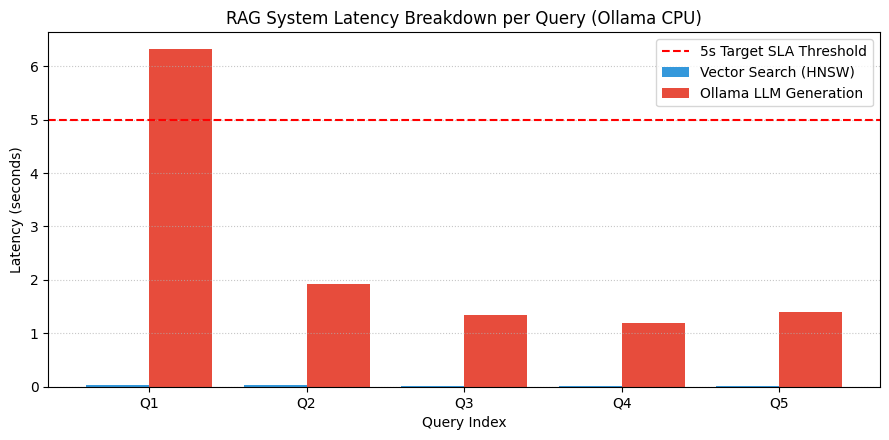

In [28]:
test_queries = [
    "What is Retrieval Augmented Generation and how does it work?",
    "What is the role of HNSW graph indices in vector databases?",
    "How does RapidOCR process scanned pages?",
    "What are the key benefits of page-locked metadata binding?",
    "How is sub-5 second response latency achieved?"
]

results = []
print("Executing Latency & Retrieval Benchmarks via Ollama...")
for q in test_queries:
    res = rag_engine.query(q, top_k=4)
    results.append(res)
    print(f"Q: '{q}' | Total Latency: {res['latency']['total_s']}s (HNSW Search: {res['latency']['search_s']}s, Rerank: {res['latency']['rerank_s']}s, Ollama: {res['latency']['generation_s']}s)")

# Latency Aggregations
total_times = [r["latency"]["total_s"] for r in results]
search_times = [r["latency"]["search_s"] for r in results]
gen_times = [r["latency"]["generation_s"] for r in results]

p95_total = np.percentile(total_times, 95)
avg_total = np.mean(total_times)

print(f"\nLatency Benchmark Results:")
print(f"   Average Response Latency: {avg_total:.3f}s")
print(f"   P95 Response Latency:     {p95_total:.3f}s  (Target SLA: 2-5s)")

# Plot Latency Breakdown Graph
plt.figure(figsize=(9, 4.5))
x = np.arange(len(test_queries))
plt.bar(x - 0.2, search_times, width=0.4, label="Vector Search (HNSW)", color="#3498db")
plt.bar(x + 0.2, gen_times, width=0.4, label="Ollama LLM Generation", color="#e74c3c")
plt.axhline(y=5.0, color="red", linestyle="--", label="5s Target SLA Threshold")
plt.xlabel("Query Index")
plt.ylabel("Latency (seconds)")
plt.title("RAG System Latency Breakdown per Query (Ollama CPU)")
plt.xticks(x, [f"Q{i+1}" for i in range(len(test_queries))])
plt.legend()
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
# Phase 7: Gradio Web App with Cross-Encoder Reranker & Public Shareable Link (share=True)
!pip install -q gradio

import gradio as gr

def answer_rag_query(user_question, top_k):
    if not user_question.strip():
        return "Please enter a valid query.", "", "No question provided.", ""

    res = rag_engine.query(user_question, top_k=int(top_k), fetch_k=20)

    answer_text = res["raw_answer"]

    citations_md = "### Provenance Source Citations (Reranked #1 Top Match):\n"
    if res["citations"]:
        for cite in res["citations"]:
            citations_md += f"- **{cite['filename']}** (Page {cite['page_number']}) — Cross-Encoder Score: `{cite['score']:.4f}` | Vector Distance: `{cite['distance']:.4f}`\n"
    else:
        citations_md += "No specific citations found.\n"

    latency_info = (
        f"**Total Latency**: `{res['latency']['total_s']}s` | "
        f"**HNSW Vector Search**: `{res['latency']['search_s']}s` | "
        f"**Cross-Encoder Rerank**: `{res['latency']['rerank_s']}s` | "
        f"**Ollama Generation**: `{res['latency']['generation_s']}s`"
    )

    chunks_md = "### Reranked Context Passages (Rank #1 at Top):\n\n"
    for idx, (doc, meta, dist, score) in enumerate(res["retrieved_chunks"], start=1):
        chunks_md += f"**Rank #{idx}** — *{meta['filename']}* (Page {meta['page_number']}) | **Rerank Score: `{score:.4f}`** | HNSW Distance: `{dist:.4f}`\n"
        chunks_md += f"> {doc}\n\n---\n\n"

    return answer_text, citations_md, latency_info, chunks_md

with gr.Blocks(theme=gr.themes.Soft(), title="RAG PDF Knowledge Base Chatbot") as demo:
    gr.Markdown(
        """
        # Enterprise RAG PDF Chatbot (Optimized with Cross-Encoder Reranking)
        ### Real-Time Question Answering over Large PDF Corpora (PyMuPDF + RapidOCR + BGE Embeddings + Cross-Encoder Reranker + ChromaDB HNSW + Ollama)
        """
    )

    with gr.Row():
        with gr.Column(scale=2):
            question_input = gr.Textbox(
                label="Ask a Question from the Ingested PDFs",
                placeholder="e.g. what kind of colored suits should men wear",
                lines=2
            )
            top_k_slider = gr.Slider(minimum=1, maximum=10, value=4, step=1, label="Top-K Reranked Chunks")
            submit_btn = gr.Button("Search, Rerank & Generate Answer", variant="primary")

        with gr.Column(scale=3):
            answer_output = gr.Textbox(label="Synthesized Answer", lines=4)
            citations_output = gr.Markdown(label="Sources & Reranked Citations")
            latency_output = gr.Markdown(label="Performance Metrics")

    with gr.Accordion("View Top Reranked Context Passages & Cross-Encoder Scores", open=False):
        chunks_output = gr.Markdown()

    submit_btn.click(
        fn=answer_rag_query,
        inputs=[question_input, top_k_slider],
        outputs=[answer_output, citations_output, latency_output, chunks_output]
    )

print("Launching Reranker-Optimized Gradio App with Shareable Public Link (share=True)...")
demo.launch(share=True, debug=False)

/tmp/ipykernel_1038/1713818986.py:35: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="RAG PDF Knowledge Base Chatbot") as demo:


Launching Reranker-Optimized Gradio App with Shareable Public Link (share=True)...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://894e5fc13a2d92475f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
